### B5: Tuned Pipeline — Optuna Hyperparameter Optimization

Same data as B4 (tech + fundamentals + sector + FinBERT + news sentiment), but with hyperparameter tuning via Optuna for each model.

In [1]:
import polars as pl
import numpy as np
import os, joblib, pickle
from datetime import date

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
)

import optuna
import warnings
warnings.filterwarnings("ignore")

print(f"Optuna version: {optuna.__version__}")

Optuna version: 4.9.0


/Users/richardpears/github/Post-Earnings-Forecast/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Data Loading (identical to B4)

In [2]:
# ── Tech modeling table
tech_path = "data/tech_modeling_table.parquet"
df_tech   = pl.read_parquet(tech_path)
print(f"Tech table shape: {df_tech.shape}")

# ── Fundamental features
fund_path = "../data/model_staging/fundamentalIndicators/modeling_fundamentals.parquet"
df_fund   = pl.read_parquet(fund_path)

df_fund = df_fund.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "eps_growth_qoq", "revenue_growth_qoq",
    "gross_margin",     "gross_margin_qoq",
    "debt_to_equity",   "debt_to_equity_qoq",
    "fcf_margin",       "fcf_margin_qoq",
    "roe",              "roe_qoq",
])

# ── FinBERT transcript sentiment
df_finbert = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
df_finbert = df_finbert.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "pos_prob", "neg_prob",
])
print(f"FinBERT shape: {df_finbert.shape}")

# ── News sentiment (pre/post earnings window)
df_nz = pl.read_parquet("../data/model_staging/nz_sentiment.parquet")
df_nz = df_nz.select([
    "symbol",
    pl.col("reportedDate").alias("earnings_date"),
    "overall_sentiment_score_pre",  "ticker_sentiment_score_pre",
    "overall_sentiment_score_post", "ticker_sentiment_score_post",
])
print(f"NZ sentiment shape: {df_nz.shape}")

# ── Merge all onto tech table
df_model = df_tech.join(df_fund,    on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_finbert, on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_nz,     on=["symbol", "earnings_date"], how="left")

print(f"Combined table shape: {df_model.shape}")
print(f"Target: {df_model['target_direction'].mean():.1%} positive")

Tech table shape: (24048, 220)
FinBERT shape: (24294, 4)
NZ sentiment shape: (24294, 6)
Combined table shape: (24048, 236)
Target: 56.3% positive


In [3]:
# ── Sector dummies
df_sector_raw = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
df_sector     = df_sector_raw.select(["symbol", "sector"]).unique()

df_sector = df_sector.with_columns(
    pl.col("sector").fill_null("Unknown")
)

sectors   = sorted(df_sector["sector"].unique().to_list())
df_sector = df_sector.with_columns([
    (pl.col("sector") == s).cast(pl.Int8).alias(f"sector_{s.replace(' ', '_')}")
    for s in sectors
]).drop("sector")

print(f"Sectors: {sectors}")
print(f"Unique symbols in sector map: {df_sector.shape[0]}")

df_model     = df_model.join(df_sector, on="symbol", how="left")
sector_cols  = [c for c in df_model.columns if c.startswith("sector_")]
print(f"Shape after sector join: {df_model.shape}")
print(f"Sector columns: {sector_cols}")

Sectors: ['Basic Materials', 'Communication Services', 'Consumer Cyclical', 'Consumer Defensive', 'Energy', 'Financial Services', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Unknown', 'Utilities']
Unique symbols in sector map: 503
Shape after sector join: (24048, 248)
Sector columns: ['sector_Basic_Materials', 'sector_Communication_Services', 'sector_Consumer_Cyclical', 'sector_Consumer_Defensive', 'sector_Energy', 'sector_Financial_Services', 'sector_Healthcare', 'sector_Industrials', 'sector_Real_Estate', 'sector_Technology', 'sector_Unknown', 'sector_Utilities']


---
## 2. Fold Setup (identical to B4)

In [4]:
TRAIN_WINDOW = 7
FOLDS = [
    (date(y - TRAIN_WINDOW, 1, 1), date(y, 1, 1), date(y + 1, 1, 1))
    for y in range(2021, 2026)
]

EXCLUDE_COLS = [
    "symbol", "earnings_date", "entry_price", "target_return",
    "target_direction", "max_high", "min_high", "max_day", "min_day",
]
feature_cols = [c for c in df_model.columns if c not in EXCLUDE_COLS]
print(f"Total features: {len(feature_cols)}")

folds_data = []

for fold_num, (train_start, test_start, test_end) in enumerate(FOLDS, 1):
    train = df_model.filter(
        (pl.col("earnings_date") >= train_start) & (pl.col("earnings_date") < test_start)
    )
    test = df_model.filter(
        (pl.col("earnings_date") >= test_start) & (pl.col("earnings_date") < test_end)
    )

    X_train = train.select(feature_cols).to_numpy()
    X_test  = test.select(feature_cols).to_numpy()

    X_train = np.where(np.isinf(X_train), np.nan, X_train)
    X_test  = np.where(np.isinf(X_test),  np.nan, X_test)

    imputer    = SimpleImputer(strategy="median")
    X_train    = imputer.fit_transform(X_train)
    X_test     = imputer.transform(X_test)

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    folds_data.append({
        "fold_num":    fold_num,
        "train_years": f"{train_start.year}-{test_start.year - 1}",
        "test_year":   test_start.year,
        "X_train":     X_train,    "X_test":     X_test,
        "X_train_sc":  X_train_sc, "X_test_sc":  X_test_sc,
        "y_train_cls": train["target_direction"].to_numpy(),
        "y_test_cls":  test["target_direction"].to_numpy(),
        "y_train_ret": train["target_return"].to_numpy(),
        "y_test_ret":  test["target_return"].to_numpy(),
    })

    print(f"Fold {fold_num}: train [{train_start.year}-{test_start.year-1}] "
          f"({X_train.shape[0]:,}) -> test [{test_start.year}] ({X_test.shape[0]:,})")

Total features: 244
Fold 1: train [2014-2020] (13,169) -> test [2021] (1,970)
Fold 2: train [2015-2021] (13,313) -> test [2022] (1,975)
Fold 3: train [2016-2022] (13,439) -> test [2023] (1,984)
Fold 4: train [2017-2023] (13,560) -> test [2024] (2,000)
Fold 5: train [2018-2024] (13,671) -> test [2025] (2,008)


---
## 3. B0 Baseline (from B4, for reference)

In [5]:
np.random.seed(42)

b0_clf = {"fold_acc": [], "preds": [], "true": []}
b0_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}

for f in folds_data:
    preds_dir = np.random.randint(0, 2, size=len(f["y_test_cls"]))
    acc = accuracy_score(f["y_test_cls"], preds_dir)
    b0_clf["fold_acc"].append(acc)
    b0_clf["preds"].extend(preds_dir)
    b0_clf["true"].extend(f["y_test_cls"])

    preds_ret = np.full(len(f["y_test_ret"]), f["y_train_ret"].mean())
    b0_reg["fold_mae"].append(mean_absolute_error(f["y_test_ret"], preds_ret))
    b0_reg["fold_rmse"].append(np.sqrt(mean_squared_error(f["y_test_ret"], preds_ret)))
    b0_reg["preds"].extend(preds_ret)
    b0_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']}: DA={acc:.4f}")

print(f"\nB0 Baseline — Avg DA:   {np.mean(b0_clf['fold_acc']):.4f}")
print(f"B0 Baseline — Avg MAE:  {np.mean(b0_reg['fold_mae']):.4f}")
print(f"B0 Baseline — Avg RMSE: {np.mean(b0_reg['fold_rmse']):.4f}")

Fold 1: DA=0.5036
Fold 2: DA=0.5084
Fold 3: DA=0.5121
Fold 4: DA=0.4980
Fold 5: DA=0.5075

B0 Baseline — Avg DA:   0.5059
B0 Baseline — Avg MAE:  0.0419
B0 Baseline — Avg RMSE: 0.0576


---
## 4. Optuna Tuning

We use fold 1's training data (2014-2020) split temporally:
- **train_sub**: 2014-2019 (used to train)
- **val**: 2020 (used to evaluate during tuning)

This respects temporal ordering and avoids data leakage.

In [6]:
# Build validation split from fold 1's training data
f1 = folds_data[0]

val_start  = date(2020, 1, 1)
train1 = df_model.filter(
    (pl.col("earnings_date") >= FOLDS[0][0]) & (pl.col("earnings_date") < val_start)
)
val1 = df_model.filter(
    (pl.col("earnings_date") >= val_start) & (pl.col("earnings_date") < FOLDS[0][1])
)

def prepare_split(df):
    X = df.select(feature_cols).to_numpy()
    X = np.where(np.isinf(X), np.nan, X)
    imputer = SimpleImputer(strategy="median")
    X = imputer.fit_transform(X)
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X)
    return {
        "X": X, "X_sc": X_sc,
        "y_cls": df["target_direction"].to_numpy(),
        "y_ret": df["target_return"].to_numpy(),
    }

train_sub = prepare_split(train1)
val_sub   = prepare_split(val1)

print(f"Train sub: {train_sub['X'].shape[0]:,} samples (2014-2019)")
print(f"Val sub:   {val_sub['X'].shape[0]:,} samples (2020)")

Train sub: 11,230 samples (2014-2019)
Val sub:   1,939 samples (2020)


### 4a. Logistic Regression Tuning

In [7]:
def objective_lr(trial):
    C       = trial.suggest_float("C", 1e-3, 1e3, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    solver  = "saga"

    model = LogisticRegression(
        C=C, penalty=penalty, solver=solver,
        max_iter=2000, class_weight="balanced",
        random_state=42, n_jobs=-1,
    )
    model.fit(train_sub["X_sc"], train_sub["y_cls"])
    preds = model.predict(val_sub["X_sc"])
    return accuracy_score(val_sub["y_cls"], preds)

study_lr = optuna.create_study(direction="maximize", study_name="lr_clf")
study_lr.optimize(objective_lr, n_trials=30, show_progress_bar=True)

print(f"\nBest LR params: {study_lr.best_params}")
print(f"Best val DA: {study_lr.best_value:.4f}")

[I 2026-06-23 18:18:08,214] A new study created in memory with name: lr_clf
Best trial: 0. Best value: 0.513667:   3%|▎         | 1/30 [00:24<11:51, 24.54s/it]

[I 2026-06-23 18:18:32,761] Trial 0 finished with value: 0.5136668385765859 and parameters: {'C': 0.7881010145211782, 'penalty': 'l2'}. Best is trial 0 with value: 0.5136668385765859.


Best trial: 1. Best value: 0.516245:   7%|▋         | 2/30 [01:09<17:01, 36.46s/it]

[I 2026-06-23 18:19:17,575] Trial 1 finished with value: 0.516245487364621 and parameters: {'C': 6.0276718211665, 'penalty': 'l1'}. Best is trial 1 with value: 0.516245487364621.


Best trial: 1. Best value: 0.516245:  10%|█         | 3/30 [01:32<13:46, 30.61s/it]

...

[I 2026-06-23 18:24:52,738] Trial 27 finished with value: 0.4878803506962352 and parameters: {'C': 0.0029335608539723932, 'penalty': 'l1'}. Best is trial 6 with value: 0.589994842702424.


Best trial: 6. Best value: 0.589995:  97%|█████████▋| 29/30 [06:47<00:05,  5.11s/it]

[I 2026-06-23 18:24:55,814] Trial 28 finished with value: 0.5100567302733368 and parameters: {'C': 0.010298782742854859, 'penalty': 'l1'}. Best is trial 6 with value: 0.589994842702424.


Best trial: 6. Best value: 0.589995: 100%|██████████| 30/30 [07:13<00:00, 14.45s/it]

[I 2026-06-23 18:25:21,679] Trial 29 finished with value: 0.5110881897885508 and parameters: {'C': 0.18572370428939836, 'penalty': 'l2'}. Best is trial 6 with value: 0.589994842702424.

Best LR params: {'C': 0.0015081008080767935, 'penalty': 'l1'}
Best val DA: 0.5900


### 4b. Ridge Regression Tuning (replaces LinearRegression)

In [8]:
def objective_ridge(trial):
    alpha = trial.suggest_float("alpha", 1e-2, 1e3, log=True)

    model = Ridge(alpha=alpha, random_state=42)
    model.fit(train_sub["X_sc"], train_sub["y_ret"])
    preds = model.predict(val_sub["X_sc"])
    return -mean_absolute_error(val_sub["y_ret"], preds)

study_ridge = optuna.create_study(direction="maximize", study_name="ridge_reg")
study_ridge.optimize(objective_ridge, n_trials=30, show_progress_bar=True)

print(f"\nBest Ridge params: {study_ridge.best_params}")
print(f"Best val MAE: {-study_ridge.best_value:.4f}")

[I 2026-06-23 18:25:21,699] A new study created in memory with name: ridge_reg
Best trial: 10. Best value: -0.0594524:  33%|███▎      | 10/30 [00:00<00:00, 55.10it/s]

[I 2026-06-23 18:25:21,762] Trial 0 finished with value: -0.06062691595018221 and parameters: {'alpha': 2.5003435732463175}. Best is trial 0 with value: -0.06062691595018221.
[I 2026-06-23 18:25:21,771] Trial 1 finished with value: -0.05947416880875356 and parameters: {'alpha': 678.8821536487062}. Best is trial 1 with value: -0.05947416880875356.
[I 2026-06-23 18:25:21,781] Trial 2 finished with value: -0.06003018057578187 and parameters: {'alpha': 11.74593074890051}. Best is trial 1 with value: -0.05947416880875356.
[I 2026-06-23 18:25:21,790] Trial 3 finished with value: -0.06154070481379742 and parameters: {'alpha': 0.012794233125291812}. Best is trial 1 with value: -0.05947416880875356.
[I 2026-06-23 18:25:21,800] Trial 4 finished with value: -0.060716643675658905 and parameters: {'alpha': 1.9781889141968678}. Best is trial 1 with value: -0.05947416880875356.
[I 2026-06-23 18:25:21,809] Trial 5 finished with value: -0.05949377466018448 and parameters: {'alpha': 504.32134280412845}.

Best trial: 10. Best value: -0.0594524:  60%|██████    | 18/30 [00:00<00:00, 72.74it/s]

[I 2026-06-23 18:25:21,884] Trial 11 finished with value: -0.05947336124522954 and parameters: {'alpha': 686.8512608667842}. Best is trial 10 with value: -0.059452434682717985.
[I 2026-06-23 18:25:21,894] Trial 12 finished with value: -0.0596437472978662 and parameters: {'alpha': 94.61252995135865}. Best is trial 10 with value: -0.059452434682717985.
[I 2026-06-23 18:25:21,904] Trial 13 finished with value: -0.0596460013880052 and parameters: {'alpha': 93.13064698125683}. Best is trial 10 with value: -0.059452434682717985.
[I 2026-06-23 18:25:21,914] Trial 14 finished with value: -0.0596191898771122 and parameters: {'alpha': 112.47936565742481}. Best is trial 10 with value: -0.059452434682717985.
[I 2026-06-23 18:25:21,925] Trial 15 finished with value: -0.05946564131162041 and parameters: {'alpha': 768.116506664748}. Best is trial 10 with value: -0.059452434682717985.
[I 2026-06-23 18:25:21,939] Trial 16 finished with value: -0.059802033941354964 and parameters: {'alpha': 33.695037210

Best trial: 19. Best value: -0.0594472: 100%|██████████| 30/30 [00:00<00:00, 79.82it/s]

[I 2026-06-23 18:25:21,970] Trial 19 finished with value: -0.05944720598520318 and parameters: {'alpha': 999.474096873662}. Best is trial 19 with value: -0.05944720598520318.
[I 2026-06-23 18:25:21,980] Trial 20 finished with value: -0.059562713862297355 and parameters: {'alpha': 195.6515488913632}. Best is trial 19 with value: -0.05944720598520318.
[I 2026-06-23 18:25:21,991] Trial 21 finished with value: -0.059451248228105553 and parameters: {'alpha': 940.364767095442}. Best is trial 19 with value: -0.05944720598520318.
[I 2026-06-23 18:25:22,001] Trial 22 finished with value: -0.05953349382815081 and parameters: {'alpha': 290.9866014613834}. Best is trial 19 with value: -0.05944720598520318.
[I 2026-06-23 18:25:22,012] Trial 23 finished with value: -0.05944833633411406 and parameters: {'alpha': 982.1270110248133}. Best is trial 19 with value: -0.05944720598520318.
[I 2026-06-23 18:25:22,024] Trial 24 finished with value: -0.059754740471011446 and parameters: {'alpha': 44.99344909779

### 4c. Random Forest Tuning

In [10]:
def objective_rf_clf(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 100, step=25)
    max_depth    = trial.suggest_int("max_depth", 3, 12)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)

    model = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_split=min_samples_split,
        class_weight="balanced", random_state=42, n_jobs=-1,
    )
    model.fit(train_sub["X"], train_sub["y_cls"])
    preds = model.predict(val_sub["X"])
    return accuracy_score(val_sub["y_cls"], preds)

study_rf_clf = optuna.create_study(direction="maximize", study_name="rf_clf")
study_rf_clf.optimize(objective_rf_clf, n_trials=8, show_progress_bar=True)

print(f"\nBest RF (clf) params: {study_rf_clf.best_params}")
print(f"Best val DA: {study_rf_clf.best_value:.4f}")

[I 2026-06-23 18:31:25,221] A new study created in memory with name: rf_clf
Best trial: 0. Best value: 0.554925:   8%|▊         | 1/12 [00:05<00:56,  5.15s/it]

[I 2026-06-23 18:31:30,371] Trial 0 finished with value: 0.554925219185147 and parameters: {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 2}. Best is trial 0 with value: 0.554925219185147.


Best trial: 0. Best value: 0.554925:  17%|█▋        | 2/12 [00:07<00:37,  3.71s/it]

[I 2026-06-23 18:31:33,066] Trial 1 finished with value: 0.5353274883960805 and parameters: {'n_estimators': 100, 'max_depth': 17, 'min_samples_split': 6}. Best is trial 0 with value: 0.554925219185147.


Best trial: 2. Best value: 0.563177:  25%|██▌       | 3/12 [00:13<00:40,  4.54s/it]

...

[I 2026-06-23 18:31:54,167] Trial 9 finished with value: 0.554925219185147 and parameters: {'n_estimators': 100, 'max_depth': 19, 'min_samples_split': 7}. Best is trial 8 with value: 0.5709128416709645.


Best trial: 8. Best value: 0.570913:  92%|█████████▏| 11/12 [00:30<00:02,  2.30s/it]

[I 2026-06-23 18:31:55,834] Trial 10 finished with value: 0.5141825683341928 and parameters: {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 10}. Best is trial 8 with value: 0.5709128416709645.


Best trial: 8. Best value: 0.570913: 100%|██████████| 12/12 [00:35<00:00,  2.94s/it]

[I 2026-06-23 18:32:00,441] Trial 11 finished with value: 0.5497679216090768 and parameters: {'n_estimators': 200, 'max_depth': 13, 'min_samples_split': 4}. Best is trial 8 with value: 0.5709128416709645.

Best RF (clf) params: {'n_estimators': 100, 'max_depth': 18, 'min_samples_split': 6}
Best val DA: 0.5709


In [12]:
def objective_rf_reg(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 100, step=25)
    max_depth    = trial.suggest_int("max_depth", 3, 12)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)

    model = RandomForestRegressor(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42, n_jobs=-1,
    )
    model.fit(train_sub["X"], train_sub["y_ret"])
    preds = model.predict(val_sub["X"])
    return -mean_absolute_error(val_sub["y_ret"], preds)

study_rf_reg = optuna.create_study(direction="maximize", study_name="rf_reg")
study_rf_reg.optimize(objective_rf_reg, n_trials=8, show_progress_bar=True)

print(f"\nBest RF (reg) params: {study_rf_reg.best_params}")
print(f"Best val MAE: {-study_rf_reg.best_value:.4f}")

[I 2026-06-23 18:36:24,986] A new study created in memory with name: rf_reg
Best trial: 0. Best value: -0.0593672:  12%|█▎        | 1/8 [00:07<00:49,  7.05s/it]

[I 2026-06-23 18:36:32,033] Trial 0 finished with value: -0.05936717126046864 and parameters: {'n_estimators': 75, 'max_depth': 3, 'min_samples_split': 5}. Best is trial 0 with value: -0.05936717126046864.


Best trial: 0. Best value: -0.0593672:  25%|██▌       | 2/8 [00:20<01:04, 10.81s/it]

[I 2026-06-23 18:36:45,474] Trial 1 finished with value: -0.060004691660727326 and parameters: {'n_estimators': 50, 'max_depth': 9, 'min_samples_split': 3}. Best is trial 0 with value: -0.05936717126046864.


Best trial: 0. Best value: -0.0593672:  38%|███▊      | 3/8 [00:43<01:22, 16.49s/it]

...

[I 2026-06-23 18:38:07,839] Trial 5 finished with value: -0.05932409725993294 and parameters: {'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 7}. Best is trial 5 with value: -0.05932409725993294.


Best trial: 5. Best value: -0.0593241:  88%|████████▊ | 7/8 [01:55<00:15, 15.49s/it]

[I 2026-06-23 18:38:20,085] Trial 6 finished with value: -0.060072900065845 and parameters: {'n_estimators': 50, 'max_depth': 8, 'min_samples_split': 4}. Best is trial 5 with value: -0.05932409725993294.


Best trial: 5. Best value: -0.0593241: 100%|██████████| 8/8 [02:14<00:00, 16.80s/it]

[I 2026-06-23 18:38:39,409] Trial 7 finished with value: -0.059896036122603885 and parameters: {'n_estimators': 75, 'max_depth': 9, 'min_samples_split': 3}. Best is trial 5 with value: -0.05932409725993294.

Best RF (reg) params: {'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 7}
Best val MAE: 0.0593


### 4d. XGBoost Tuning

In [13]:
def objective_xgb_clf(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 300, step=50),
        "max_depth":         trial.suggest_int("max_depth", 3, 15),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0, 5),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "eval_metric":       "logloss",
        "random_state":      42,
    }
    model = XGBClassifier(**params)
    model.fit(train_sub["X"], train_sub["y_cls"])
    preds = model.predict(val_sub["X"])
    return accuracy_score(val_sub["y_cls"], preds)

study_xgb_clf = optuna.create_study(direction="maximize", study_name="xgb_clf")
study_xgb_clf.optimize(objective_xgb_clf, n_trials=15, show_progress_bar=True)

print(f"\nBest XGB (clf) params: {study_xgb_clf.best_params}")
print(f"Best val DA: {study_xgb_clf.best_value:.4f}")

[I 2026-06-23 18:38:52,635] A new study created in memory with name: xgb_clf
Best trial: 0. Best value: 0.559567:   7%|▋         | 1/15 [00:04<00:57,  4.11s/it]

[I 2026-06-23 18:38:56,745] Trial 0 finished with value: 0.5595667870036101 and parameters: {'n_estimators': 50, 'max_depth': 10, 'learning_rate': 0.03529936606981327, 'subsample': 0.9063673268977888, 'colsample_bytree': 0.7312028317301498, 'min_child_weight': 3, 'gamma': 1.3547702541974216, 'reg_alpha': 0.696664812457845, 'reg_lambda': 2.881401665171891}. Best is trial 0 with value: 0.5595667870036101.


Best trial: 0. Best value: 0.559567:  13%|█▎        | 2/15 [00:06<00:42,  3.23s/it]

[I 2026-06-23 18:38:59,367] Trial 1 finished with value: 0.5353274883960805 and parameters: {'n_estimators': 200, 'max_depth': 11, 'learning_rate': 0.09475238462301735, 'subsample': 0.7732175435116424, 'colsample_bytree': 0.3214558017637956, 'min_child_weight': 8, 'gamma': 3.2532065266929697, 'reg_alpha': 1.117117806408436, 'reg_lambda': 0.003073422669142156}. Best is trial 0 with value: 0.5595667870036101.


Best trial: 0. Best value: 0.559567:  20%|██        | 3/15 [00:10<00:40,  3.38s/it]

...

[I 2026-06-23 18:39:41,265] Trial 12 finished with value: 0.5879319236719959 and parameters: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.011004372039256395, 'subsample': 0.9983019820720764, 'colsample_bytree': 0.488659039604251, 'min_child_weight': 1, 'gamma': 0.27103491416482584, 'reg_alpha': 9.69464409460056, 'reg_lambda': 8.864859625221023}. Best is trial 10 with value: 0.589994842702424.


Best trial: 10. Best value: 0.589995:  93%|█████████▎| 14/15 [00:49<00:01,  1.36s/it]

[I 2026-06-23 18:39:41,657] Trial 13 finished with value: 0.5889633831872099 and parameters: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.016762023757879527, 'subsample': 0.99269100209875, 'colsample_bytree': 0.5150982611839953, 'min_child_weight': 1, 'gamma': 0.022209169011302488, 'reg_alpha': 9.06798845968153, 'reg_lambda': 8.561545801444437}. Best is trial 10 with value: 0.589994842702424.


Best trial: 10. Best value: 0.589995: 100%|██████████| 15/15 [00:50<00:00,  3.38s/it]

[I 2026-06-23 18:39:43,367] Trial 14 finished with value: 0.5863847343991748 and parameters: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.010035421836359333, 'subsample': 0.9336605327265778, 'colsample_bytree': 0.516873551577009, 'min_child_weight': 1, 'gamma': 0.7609730058969484, 'reg_alpha': 3.4523143270743297, 'reg_lambda': 1.8326877752848014}. Best is trial 10 with value: 0.589994842702424.

Best XGB (clf) params: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.010086628918919146, 'subsample': 0.9980918052968162, 'colsample_bytree': 0.49165363693990405, 'min_child_weight': 1, 'gamma': 0.2378350216519567, 'reg_alpha': 9.304074248913436, 'reg_lambda': 6.7894005795991506}
Best val DA: 0.5900


In [14]:
def objective_xgb_reg(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 300, step=50),
        "max_depth":         trial.suggest_int("max_depth", 3, 15),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0, 5),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "random_state":      42,
    }
    model = XGBRegressor(**params)
    model.fit(train_sub["X"], train_sub["y_ret"])
    preds = model.predict(val_sub["X"])
    return -mean_absolute_error(val_sub["y_ret"], preds)

study_xgb_reg = optuna.create_study(direction="maximize", study_name="xgb_reg")
study_xgb_reg.optimize(objective_xgb_reg, n_trials=15, show_progress_bar=True)

print(f"\nBest XGB (reg) params: {study_xgb_reg.best_params}")
print(f"Best val MAE: {-study_xgb_reg.best_value:.4f}")

[I 2026-06-23 18:39:43,387] A new study created in memory with name: xgb_reg
Best trial: 0. Best value: -0.0595431:   7%|▋         | 1/15 [00:00<00:11,  1.20it/s]

[I 2026-06-23 18:39:44,225] Trial 0 finished with value: -0.05954305569418691 and parameters: {'n_estimators': 300, 'max_depth': 13, 'learning_rate': 0.023681319722922565, 'subsample': 0.9181449750006866, 'colsample_bytree': 0.6505605757743692, 'min_child_weight': 6, 'gamma': 3.9268061804642294, 'reg_alpha': 0.011155065280774897, 'reg_lambda': 0.012912488769946242}. Best is trial 0 with value: -0.05954305569418691.


Best trial: 1. Best value: -0.059542:  13%|█▎        | 2/15 [00:01<00:10,  1.25it/s] 

[I 2026-06-23 18:39:44,995] Trial 1 finished with value: -0.059541987146106076 and parameters: {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.07725115613718497, 'subsample': 0.9166834420517858, 'colsample_bytree': 0.5083573684840554, 'min_child_weight': 3, 'gamma': 2.263573089623427, 'reg_alpha': 0.0011690475170959588, 'reg_lambda': 0.9592173639048096}. Best is trial 1 with value: -0.059541987146106076.


Best trial: 1. Best value: -0.059542:  20%|██        | 3/15 [00:02<00:07,  1.53it/s]

...

[I 2026-06-23 18:39:49,779] Trial 12 finished with value: -0.05954284685938879 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01466535816553193, 'subsample': 0.6016650145511393, 'colsample_bytree': 0.8879575250453502, 'min_child_weight': 7, 'gamma': 1.9075104647300827, 'reg_alpha': 0.02960593142748654, 'reg_lambda': 0.0012368869385547363}. Best is trial 3 with value: -0.059448785512054146.


Best trial: 3. Best value: -0.0594488:  93%|█████████▎| 14/15 [00:07<00:00,  1.77it/s]

[I 2026-06-23 18:39:50,454] Trial 13 finished with value: -0.059544570240833074 and parameters: {'n_estimators': 250, 'max_depth': 8, 'learning_rate': 0.06636621204328401, 'subsample': 0.7898308764659943, 'colsample_bytree': 0.7581629708634207, 'min_child_weight': 3, 'gamma': 4.965278719490201, 'reg_alpha': 0.007324600347739481, 'reg_lambda': 0.08860294429251449}. Best is trial 3 with value: -0.059448785512054146.


Best trial: 3. Best value: -0.0594488: 100%|██████████| 15/15 [00:07<00:00,  1.96it/s]

[I 2026-06-23 18:39:51,027] Trial 14 finished with value: -0.05953895577445962 and parameters: {'n_estimators': 150, 'max_depth': 11, 'learning_rate': 0.022647221969742, 'subsample': 0.5860109925032528, 'colsample_bytree': 0.7298116373938079, 'min_child_weight': 3, 'gamma': 0.7540191395735145, 'reg_alpha': 0.10264752449544873, 'reg_lambda': 0.006058004334678876}. Best is trial 3 with value: -0.059448785512054146.

Best XGB (reg) params: {'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.026742364196933443, 'subsample': 0.580580692197102, 'colsample_bytree': 0.7624983385037777, 'min_child_weight': 2, 'gamma': 0.10166305209634907, 'reg_alpha': 0.7999975930471641, 'reg_lambda': 0.0457712770921794}
Best val MAE: 0.0594


---
## 5. Evaluate Best Models Across All 5 Folds

In [15]:
best_params = {
    "lr":       study_lr.best_params,
    "ridge":    study_ridge.best_params,
    "rf_clf":   study_rf_clf.best_params,
    "rf_reg":   study_rf_reg.best_params,
    "xgb_clf":  study_xgb_clf.best_params,
    "xgb_reg":  study_xgb_reg.best_params,
}

print("Best hyperparameters found:")
for name, params in best_params.items():
    print(f"  {name}: {params}")

Best hyperparameters found:
  lr: {'C': 0.0015081008080767935, 'penalty': 'l1'}
  ridge: {'alpha': 999.474096873662}
  rf_clf: {'n_estimators': 100, 'max_depth': 18, 'min_samples_split': 6}
  rf_reg: {'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 7}
  xgb_clf: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.010086628918919146, 'subsample': 0.9980918052968162, 'colsample_bytree': 0.49165363693990405, 'min_child_weight': 1, 'gamma': 0.2378350216519567, 'reg_alpha': 9.304074248913436, 'reg_lambda': 6.7894005795991506}
  xgb_reg: {'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.026742364196933443, 'subsample': 0.580580692197102, 'colsample_bytree': 0.7624983385037777, 'min_child_weight': 2, 'gamma': 0.10166305209634907, 'reg_alpha': 0.7999975930471641, 'reg_lambda': 0.0457712770921794}


In [16]:
# ── Logistic Regression (tuned)
lr_clf   = {"fold_acc": [], "preds": [], "probs": [], "true": []}
lr_model = LogisticRegression(
    **best_params["lr"], solver="saga",
    max_iter=2000, class_weight="balanced", random_state=42, n_jobs=-1,
)

for f in folds_data:
    lr_model.fit(f["X_train_sc"], f["y_train_cls"])
    preds = lr_model.predict(f["X_test_sc"])
    probs = lr_model.predict_proba(f["X_test_sc"])[:, 1]
    acc = accuracy_score(f["y_test_cls"], preds)
    lr_clf["fold_acc"].append(acc)
    lr_clf["preds"].extend(preds)
    lr_clf["probs"].extend(probs)
    lr_clf["true"].extend(f["y_test_cls"])
    print(f"LR Fold {f['fold_num']} [{f['test_year']}]: DA={acc:.4f}")

print(f"\nLR (tuned) — Avg DA:     {np.mean(lr_clf['fold_acc']):.4f}")
print(f"LR (tuned) — Pooled F1:  {f1_score(np.array(lr_clf['true']), np.array(lr_clf['preds']), average='weighted'):.4f}")
print(f"LR (tuned) — Pooled AUC: {roc_auc_score(np.array(lr_clf['true']), np.array(lr_clf['probs'])):.4f}")

LR Fold 1 [2021]: DA=0.4157
LR Fold 2 [2022]: DA=0.4359
LR Fold 3 [2023]: DA=0.4995
LR Fold 4 [2024]: DA=0.6305
LR Fold 5 [2025]: DA=0.4447

LR (tuned) — Avg DA:     0.4853
LR (tuned) — Pooled F1:  0.4828
LR (tuned) — Pooled AUC: 0.5080


In [17]:
# ── Ridge Regression (tuned — replaces LinearRegression)
ridge_reg       = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
ridge_model     = Ridge(**best_params["ridge"], random_state=42)

for f in folds_data:
    ridge_model.fit(f["X_train_sc"], f["y_train_ret"])
    preds = ridge_model.predict(f["X_test_sc"])

    mae  = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    ridge_reg["fold_mae"].append(mae)
    ridge_reg["fold_rmse"].append(rmse)
    ridge_reg["preds"].extend(preds)
    ridge_reg["true"].extend(f["y_test_ret"])

    print(f"Ridge Fold {f['fold_num']} [{f['test_year']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nRidge (tuned) — Avg MAE:   {np.mean(ridge_reg['fold_mae']):.4f}")
print(f"Ridge (tuned) — Avg RMSE:  {np.mean(ridge_reg['fold_rmse']):.4f}")
print(f"Ridge (tuned) — Pooled R²: {r2_score(np.array(ridge_reg['true']), np.array(ridge_reg['preds'])):.4f}")

Ridge Fold 1 [2021]: MAE=0.0389  RMSE=0.0537
Ridge Fold 2 [2022]: MAE=0.0509  RMSE=0.0685
Ridge Fold 3 [2023]: MAE=0.0384  RMSE=0.0515
Ridge Fold 4 [2024]: MAE=0.0393  RMSE=0.0554
Ridge Fold 5 [2025]: MAE=0.0440  RMSE=0.0622

Ridge (tuned) — Avg MAE:   0.0423
Ridge (tuned) — Avg RMSE:  0.0583
Ridge (tuned) — Pooled R²: -0.0260


In [18]:
# ── Random Forest Classifier (tuned)
rf_clf       = {"fold_acc": [], "preds": [], "probs": [], "true": []}
rf_clf_model = RandomForestClassifier(
    **best_params["rf_clf"], class_weight="balanced", random_state=42, n_jobs=-1,
)

for f in folds_data:
    rf_clf_model.fit(f["X_train"], f["y_train_cls"])
    preds = rf_clf_model.predict(f["X_test"])
    probs = rf_clf_model.predict_proba(f["X_test"])[:, 1]
    acc = accuracy_score(f["y_test_cls"], preds)
    rf_clf["fold_acc"].append(acc)
    rf_clf["preds"].extend(preds)
    rf_clf["probs"].extend(probs)
    rf_clf["true"].extend(f["y_test_cls"])
    print(f"RF Fold {f['fold_num']} [{f['test_year']}]: DA={acc:.4f}")

print(f"\nRF (tuned) — Avg DA:     {np.mean(rf_clf['fold_acc']):.4f}")
print(f"RF (tuned) — Pooled F1:  {f1_score(np.array(rf_clf['true']), np.array(rf_clf['preds']), average='weighted'):.4f}")
print(f"RF (tuned) — Pooled AUC: {roc_auc_score(np.array(rf_clf['true']), np.array(rf_clf['probs'])):.4f}")

RF Fold 1 [2021]: DA=0.5467
RF Fold 2 [2022]: DA=0.5585
RF Fold 3 [2023]: DA=0.5186
RF Fold 4 [2024]: DA=0.5185
RF Fold 5 [2025]: DA=0.5224

RF (tuned) — Avg DA:     0.5329
RF (tuned) — Pooled F1:  0.5064
RF (tuned) — Pooled AUC: 0.5075


In [19]:
# ── Random Forest Regressor (tuned)
rf_reg       = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
rf_reg_model = RandomForestRegressor(
    **best_params["rf_reg"], random_state=42, n_jobs=-1,
)

for f in folds_data:
    rf_reg_model.fit(f["X_train"], f["y_train_ret"])
    preds = rf_reg_model.predict(f["X_test"])

    mae  = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    rf_reg["fold_mae"].append(mae)
    rf_reg["fold_rmse"].append(rmse)
    rf_reg["preds"].extend(preds)
    rf_reg["true"].extend(f["y_test_ret"])

    print(f"RF Fold {f['fold_num']} [{f['test_year']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nRF (tuned) — Avg MAE:   {np.mean(rf_reg['fold_mae']):.4f}")
print(f"RF (tuned) — Avg RMSE:  {np.mean(rf_reg['fold_rmse']):.4f}")
print(f"RF (tuned) — Pooled R²: {r2_score(np.array(rf_reg['true']), np.array(rf_reg['preds'])):.4f}")

RF Fold 1 [2021]: MAE=0.0386  RMSE=0.0532
RF Fold 2 [2022]: MAE=0.0510  RMSE=0.0693
RF Fold 3 [2023]: MAE=0.0377  RMSE=0.0511
RF Fold 4 [2024]: MAE=0.0386  RMSE=0.0548
RF Fold 5 [2025]: MAE=0.0437  RMSE=0.0622

RF (tuned) — Avg MAE:   0.0419
RF (tuned) — Avg RMSE:  0.0581
RF (tuned) — Pooled R²: -0.0232


In [20]:
# ── XGBoost Classifier (tuned)
xgb_clf       = {"fold_acc": [], "preds": [], "probs": [], "true": []}
xgb_clf_model = XGBClassifier(
    **best_params["xgb_clf"], eval_metric="logloss", random_state=42,
)

for f in folds_data:
    xgb_clf_model.fit(f["X_train"], f["y_train_cls"])
    preds = xgb_clf_model.predict(f["X_test"])
    probs = xgb_clf_model.predict_proba(f["X_test"])[:, 1]
    acc = accuracy_score(f["y_test_cls"], preds)
    xgb_clf["fold_acc"].append(acc)
    xgb_clf["preds"].extend(preds)
    xgb_clf["probs"].extend(probs)
    xgb_clf["true"].extend(f["y_test_cls"])
    print(f"XGB Fold {f['fold_num']} [{f['test_year']}]: DA={acc:.4f}")

print(f"\nXGB (tuned) — Avg DA:     {np.mean(xgb_clf['fold_acc']):.4f}")
print(f"XGB (tuned) — Pooled F1:  {f1_score(np.array(xgb_clf['true']), np.array(xgb_clf['preds']), average='weighted'):.4f}")
print(f"XGB (tuned) — Pooled AUC: {roc_auc_score(np.array(xgb_clf['true']), np.array(xgb_clf['probs'])):.4f}")

XGB Fold 1 [2021]: DA=0.5843
XGB Fold 2 [2022]: DA=0.5641
XGB Fold 3 [2023]: DA=0.4995
XGB Fold 4 [2024]: DA=0.6305
XGB Fold 5 [2025]: DA=0.5553

XGB (tuned) — Avg DA:     0.5667
XGB (tuned) — Pooled F1:  0.4101
XGB (tuned) — Pooled AUC: 0.5020


In [21]:
# ── XGBoost Regressor (tuned)
xgb_reg       = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
xgb_reg_model = XGBRegressor(
    **best_params["xgb_reg"], random_state=42,
)

for f in folds_data:
    xgb_reg_model.fit(f["X_train"], f["y_train_ret"])
    preds = xgb_reg_model.predict(f["X_test"])

    mae  = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    xgb_reg["fold_mae"].append(mae)
    xgb_reg["fold_rmse"].append(rmse)
    xgb_reg["preds"].extend(preds)
    xgb_reg["true"].extend(f["y_test_ret"])

    print(f"XGB Fold {f['fold_num']} [{f['test_year']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nXGB (tuned) — Avg MAE:   {np.mean(xgb_reg['fold_mae']):.4f}")
print(f"XGB (tuned) — Avg RMSE:  {np.mean(xgb_reg['fold_rmse']):.4f}")
print(f"XGB (tuned) — Pooled R²: {r2_score(np.array(xgb_reg['true']), np.array(xgb_reg['preds'])):.4f}")

XGB Fold 1 [2021]: MAE=0.0386  RMSE=0.0531
XGB Fold 2 [2022]: MAE=0.0508  RMSE=0.0680
XGB Fold 3 [2023]: MAE=0.0375  RMSE=0.0508
XGB Fold 4 [2024]: MAE=0.0385  RMSE=0.0547
XGB Fold 5 [2025]: MAE=0.0436  RMSE=0.0615

XGB (tuned) — Avg MAE:   0.0418
XGB (tuned) — Avg RMSE:  0.0576
XGB (tuned) — Pooled R²: -0.0050


---
## 6. Results Comparison — B4 (default) vs B5 (tuned)

In [22]:
print("=== Direction (Classification) — B4 (default) vs B5 (tuned) ===")
print(f"{'Model':<28} {'B4 Avg DA%':>12} {'B5 Avg DA%':>12} {'Chg':>8} {'B4 AUC':>8} {'B5 AUC':>8}")
print("-" * 80)

b4_data = {
    "LR":  {"da": 0.5761, "auc": 0.6055},
    "RF":  {"da": 0.5931, "auc": 0.6167},
    "XGB": {"da": 0.5736, "auc": 0.5902},
}

b5_data_clf = {
    "LR":  {"da": np.mean(lr_clf["fold_acc"]),       "auc": roc_auc_score(np.array(lr_clf["true"]), np.array(lr_clf["probs"]))},
    "RF":  {"da": np.mean(rf_clf["fold_acc"]),       "auc": roc_auc_score(np.array(rf_clf["true"]), np.array(rf_clf["probs"]))},
    "XGB": {"da": np.mean(xgb_clf["fold_acc"]),      "auc": roc_auc_score(np.array(xgb_clf["true"]), np.array(xgb_clf["probs"]))},
}

for name in ["LR", "RF", "XGB"]:
    b4 = b4_data[name]
    b5 = b5_data_clf[name]
    chg = b5["da"] - b4["da"]
    print(f"{name:<28} {b4['da']:>12.4f} {b5['da']:>12.4f} {chg:>+8.4f} {b4['auc']:>8.4f} {b5['auc']:>8.4f}")

print(f"\n=== Magnitude (Regression) — B4 (default) vs B5 (tuned) ===")
print(f"{'Model':<28} {'B4 R²':>10} {'B5 R²':>10} {'Chg':>8} {'B4 MAE':>10} {'B5 MAE':>10}")
print("-" * 80)

# For regression: B4 RF had R²=0.1321, MAE=0.0295; XGB had R²=-0.025, MAE=0.0321; LinReg was catastrophic
# We replaced LinReg with Ridge, so only RF and XGB are directly comparable
b4_data_reg = {
    "Ridge": {"r2": None, "mae": None},  # new model, no B4 baseline
    "RF":    {"r2": 0.1321, "mae": 0.0295},
    "XGB":   {"r2": -0.0250, "mae": 0.0321},
}

b5_data_reg = {
    "Ridge": {"r2": r2_score(np.array(ridge_reg["true"]), np.array(ridge_reg["preds"])),
               "mae": np.mean(ridge_reg["fold_mae"])},
    "RF":    {"r2": r2_score(np.array(rf_reg["true"]), np.array(rf_reg["preds"])),
               "mae": np.mean(rf_reg["fold_mae"])},
    "XGB":   {"r2": r2_score(np.array(xgb_reg["true"]), np.array(xgb_reg["preds"])),
               "mae": np.mean(xgb_reg["fold_mae"])},
}

for name in ["Ridge", "RF", "XGB"]:
    b4 = b4_data_reg[name]
    b5 = b5_data_reg[name]
    b4_r2_str = f"{b4['r2']:.4f}" if b4['r2'] is not None else "  N/A  "
    b4_mae_str = f"{b4['mae']:.4f}" if b4['mae'] is not None else "  N/A  "
    chg_r2 = b5['r2'] - b4['r2'] if b4['r2'] is not None else 0
    print(f"{name:<28} {b4_r2_str:>10} {b5['r2']:>10.4f} {chg_r2:>+8.4f} {b4_mae_str:>10} {b5['mae']:>10.4f}")

=== Direction (Classification) — B4 (default) vs B5 (tuned) ===
Model                          B4 Avg DA%   B5 Avg DA%      Chg   B4 AUC   B5 AUC
--------------------------------------------------------------------------------
LR                                 0.5761       0.4853  -0.0908   0.6055   0.5080
RF                                 0.5931       0.5329  -0.0602   0.6167   0.5075
XGB                                0.5736       0.5667  -0.0069   0.5902   0.5020

=== Magnitude (Regression) — B4 (default) vs B5 (tuned) ===
Model                             B4 R²      B5 R²      Chg     B4 MAE     B5 MAE
--------------------------------------------------------------------------------
Ridge                             N/A      -0.0260  +0.0000      N/A       0.0423
RF                               0.1321    -0.0232  -0.1553     0.0295     0.0419
XGB                             -0.0250    -0.0050  +0.0200     0.0321     0.0418


### Per-fold breakdown (B5 tuned)

In [23]:
print("=== Direction (Classification) — B5 (tuned) ===")
print(f"{'Model':<25} {'Avg DA%':>10} {'Pooled F1':>10} {'Prec':>8} {'Recall':>8} {'AUC':>8}")
print("-" * 75)

for name, r in [("B0 Random", b0_clf), ("LR (tuned)", lr_clf),
                ("RF (tuned)", rf_clf), ("XGB (tuned)", xgb_clf)]:
    true  = np.array(r["true"])
    preds = np.array(r["preds"])
    avg_acc = np.mean(r["fold_acc"])
    f1   = f1_score(true, preds, average="weighted")
    prec = precision_score(true, preds, average="weighted")
    rec  = recall_score(true, preds, average="weighted")
    auc_str = (f"{roc_auc_score(true, np.array(r['probs'])):>8.4f}"
               if r.get("probs") else f"{'—':>8}")
    print(f"{name:<25} {avg_acc:>10.4f} {f1:>10.4f} {prec:>8.4f} {rec:>8.4f} {auc_str}")

print(f"\n=== Magnitude (Regression) — B5 (tuned) ===")
print(f"{'Model':<25} {'Avg MAE':>10} {'Avg RMSE':>10} {'Pooled R²':>10}")
print("-" * 60)

for name, r in [("B0 Mean", b0_reg), ("Ridge (tuned)", ridge_reg),
                ("RF (tuned)", rf_reg), ("XGB (tuned)", xgb_reg)]:
    true  = np.array(r["true"])
    preds = np.array(r["preds"])
    print(f"{name:<25} {np.mean(r['fold_mae']):>10.4f} "
          f"{np.mean(r['fold_rmse']):>10.4f} {r2_score(true, preds):>10.4f}")

=== Direction (Classification) — B5 (tuned) ===
Model                        Avg DA%  Pooled F1     Prec   Recall      AUC
---------------------------------------------------------------------------
B0 Random                     0.5059     0.5081   0.5152   0.5059        —
LR (tuned)                    0.4853     0.4828   0.5076   0.4856   0.5080
RF (tuned)                    0.5329     0.5064   0.5105   0.5329   0.5075
XGB (tuned)                   0.5667     0.4101   0.3212   0.5668   0.5020

=== Magnitude (Regression) — B5 (tuned) ===
Model                        Avg MAE   Avg RMSE  Pooled R²
------------------------------------------------------------
B0 Mean                       0.0419     0.0576    -0.0020
Ridge (tuned)                 0.0423     0.0583    -0.0260
RF (tuned)                    0.0419     0.0581    -0.0232
XGB (tuned)                   0.0418     0.0576    -0.0050


---
## 8. Target Return Distribution by Year

Visualizing how target_return varies across years explains why tuning on a single validation year (2020) produces misleading hyperparameters.

=== Target Return by Year ===
 year  mean_return  median_return  std_return  pct_positive  count
 2014     0.009966       0.010882    0.039929      0.611720   1826
 2015     0.004772       0.004646    0.040859      0.546241   1849
 2016     0.008691       0.004680    0.050715      0.551798   1863
 2017     0.003245       0.002649    0.036389      0.538909   1889
 2018     0.004485       0.005102    0.052271      0.549550   1887
 2019     0.002148       0.006194    0.046588      0.560543   1916
 2020     0.014139       0.011310    0.090099      0.589995   1939
 2021     0.011449       0.009005    0.052989      0.584264   1970
 2022     0.006913       0.011520    0.067423      0.564051   1975
 2023     0.002389      -0.000131    0.050614      0.499496   1984
 2024     0.016196       0.014762    0.053910      0.630500   2000
 2025     0.006988       0.007031    0.061667      0.555279   2008
 2026     0.004093       0.001525    0.066928      0.510616    942



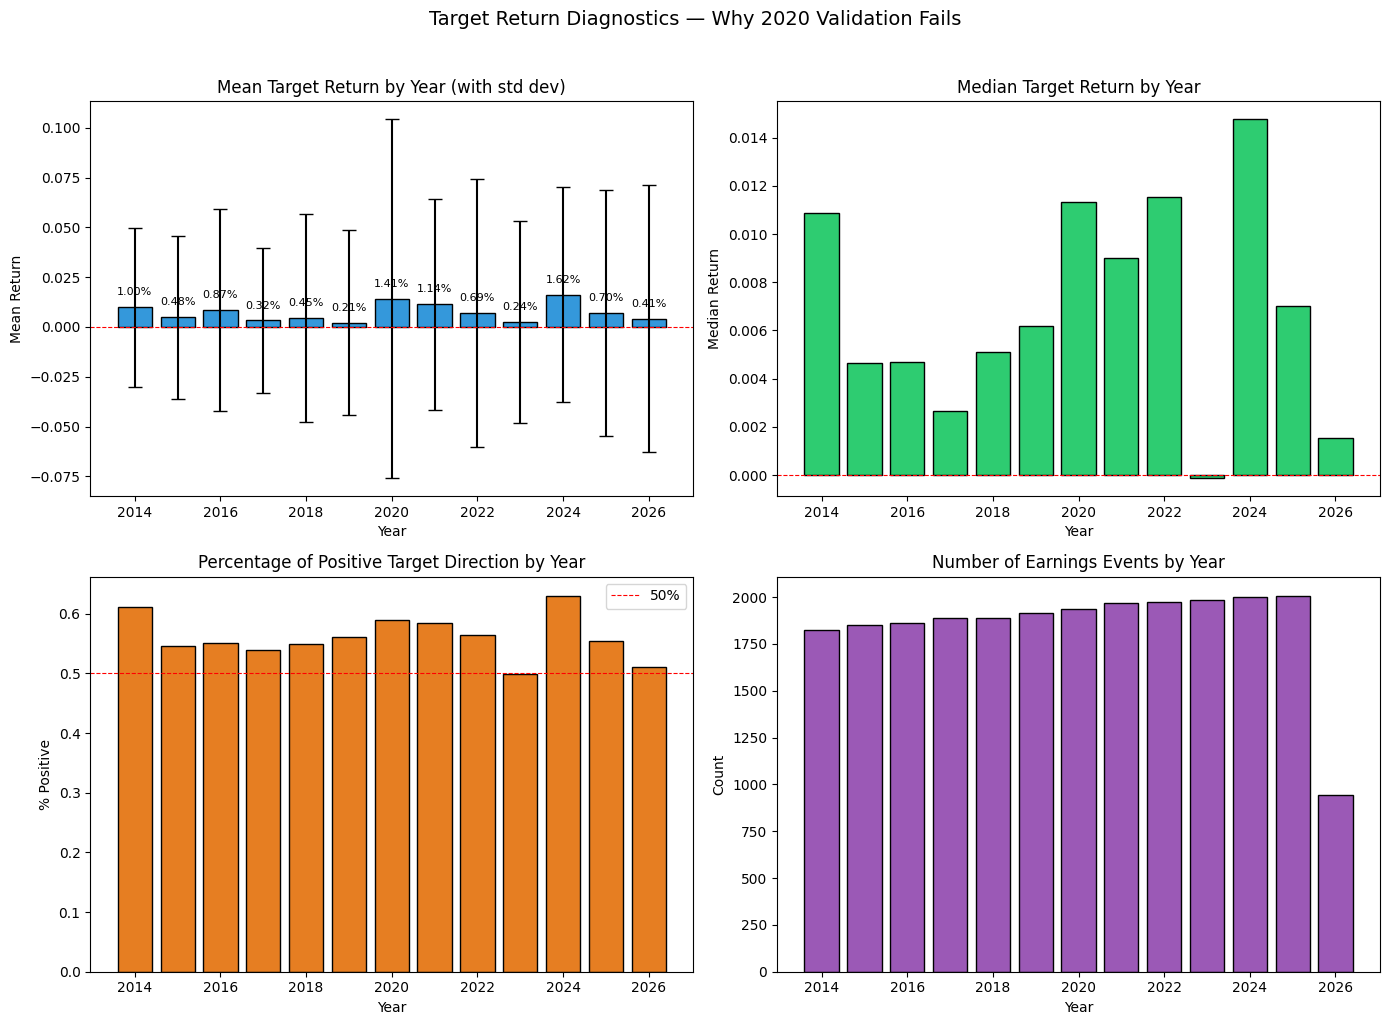


=== Temporal Split Summary ===
Fold 1 train sub (used for fitting): 2014-2019
Fold 1 val      (used by Optuna):    2020
Fold 1 test     (first test year):   2021
Fold 1 test: 2021
Fold 2 test: 2022
Fold 3 test: 2023
Fold 4 test: 2024
Fold 5 test: 2025


In [25]:
import matplotlib.pyplot as plt

# Extract year and compute yearly stats
df_plot = df_model.with_columns(
    pl.col("earnings_date").dt.year().alias("year")
)

yearly = df_plot.group_by("year").agg(
    pl.mean("target_return").alias("mean_return"),
    pl.median("target_return").alias("median_return"),
    pl.std("target_return").alias("std_return"),
    pl.mean("target_direction").alias("pct_positive"),
    pl.len().alias("count"),
).sort("year")

print("=== Target Return by Year ===")
print(yearly.to_pandas().to_string(index=False))
print()

years  = yearly["year"].to_list()
means  = yearly["mean_return"].to_list()
medians = yearly["median_return"].to_list()
stds   = yearly["std_return"].to_list()
pct_pos = yearly["pct_positive"].to_list()
counts = yearly["count"].to_list()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: mean return by year with error bars
ax = axes[0, 0]
bars = ax.bar(years, means, yerr=stds, capsize=5, color="#3498db", edgecolor="black")
ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{m:.2%}", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Year")
ax.set_ylabel("Mean Return")
ax.set_title("Mean Target Return by Year (with std dev)")

# Top-right: median return by year
ax = axes[0, 1]
ax.bar(years, medians, color="#2ecc71", edgecolor="black")
ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Median Return")
ax.set_title("Median Target Return by Year")

# Bottom-left: percentage positive by year
ax = axes[1, 0]
ax.bar(years, pct_pos, color="#e67e22", edgecolor="black")
ax.axhline(0.5, color="red", linestyle="--", linewidth=0.8, label="50%")
ax.set_xlabel("Year")
ax.set_ylabel("% Positive")
ax.set_title("Percentage of Positive Target Direction by Year")
ax.legend()

# Bottom-right: sample count by year
ax = axes[1, 1]
ax.bar(years, counts, color="#9b59b6", edgecolor="black")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.set_title("Number of Earnings Events by Year")

plt.suptitle("Target Return Diagnostics — Why 2020 Validation Fails", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print train/val/test split years
print("\n=== Temporal Split Summary ===")
print(f"Fold 1 train sub (used for fitting): 2014-2019")
print(f"Fold 1 val      (used by Optuna):    2020")
print(f"Fold 1 test     (first test year):   2021")
for f in folds_data:
    print(f"Fold {f['fold_num']} test: {f['test_year']}")

---
## 9. Single Split: XGBoost — Train up to 2023, Predict 2024-2025

Simple train/test split: use data through 2023 as training, 2024-2025 as test. Only XGBoost (default params).

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.patches import Patch

def prepare_single_split(df_model, feature_cols, train_end, test_start, test_end):
    train = df_model.filter(pl.col("earnings_date") < train_end)
    test  = df_model.filter(
        (pl.col("earnings_date") >= test_start) & (pl.col("earnings_date") < test_end)
    )

    X_train = train.select(feature_cols).to_numpy()
    X_test  = test.select(feature_cols).to_numpy()
    X_train = np.where(np.isinf(X_train), np.nan, X_train)
    X_test  = np.where(np.isinf(X_test), np.nan, X_test)
    imp = SimpleImputer(strategy="median")
    X_train = imp.fit_transform(X_train)
    X_test  = imp.transform(X_test)

    return {
        "X_train": X_train, "X_test": X_test,
        "y_train_cls": train["target_direction"].to_numpy(),
        "y_test_cls":  test["target_direction"].to_numpy(),
        "y_train_ret": train["target_return"].to_numpy(),
        "y_test_ret":  test["target_return"].to_numpy(),
        "test_years": f"{test_start.year}-{test_end.year-1}",
        "n_train": len(X_train), "n_test": len(X_test),
    }

# Split A: train up to 2023, test 2024-2025
s1 = prepare_single_split(df_model, feature_cols,
    train_end=date(2023, 1, 1), test_start=date(2024, 1, 1), test_end=date(2026, 1, 1))
print(f"Split A (train < 2024, test 2024-2025):")
print(f"  Train: {s1['n_train']:,} samples ({2014}-{2023})")
print(f"  Test:  {s1['n_test']:,} samples ({2024}-{2025})")
print(f"  Test class balance: {s1['y_test_cls'].mean():.1%} positive")
print()

# Split B: train up to 2020, test 2021-2026 (more training data, broader test)
s2 = prepare_single_split(df_model, feature_cols,
    train_end=date(2020, 1, 1), test_start=date(2021, 1, 1), test_end=date(2027, 1, 1))
print(f"Split B (train < 2021, test 2021-2026):")
print(f"  Train: {s2['n_train']:,} samples ({2014}-{2020})")
print(f"  Test:  {s2['n_test']:,} samples ({2021}-{2026})")
print(f"  Test class balance: {s2['y_test_cls'].mean():.1%} positive")

splits = [("Train<2024, Test 2024-2025", s1), ("Train<2021, Test 2021-2026", s2)]

Split A (train < 2024, test 2024-2025):
  Train: 17,114 samples (2014-2023)
  Test:  4,008 samples (2024-2025)
  Test class balance: 59.3% positive

Split B (train < 2021, test 2021-2026):
  Train: 11,230 samples (2014-2020)
  Test:  10,879 samples (2021-2026)
  Test class balance: 56.2% positive


In [27]:
results = []

for name, s in splits:
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    # ── XGBoost Classifier ──
    xgb_c = XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42)
    xgb_c.fit(s["X_train"], s["y_train_cls"])
    preds_c = xgb_c.predict(s["X_test"])
    probs_c = xgb_c.predict_proba(s["X_test"])[:, 1]

    acc  = accuracy_score(s["y_test_cls"], preds_c)
    f1   = f1_score(s["y_test_cls"], preds_c, average="weighted")
    auc  = roc_auc_score(s["y_test_cls"], probs_c)
    prec = precision_score(s["y_test_cls"], preds_c, average="weighted")
    rec  = recall_score(s["y_test_cls"], preds_c, average="weighted")

    # ── XGBoost Regressor ──
    xgb_r = XGBRegressor(n_estimators=200, random_state=42)
    xgb_r.fit(s["X_train"], s["y_train_ret"])
    preds_r = xgb_r.predict(s["X_test"])

    mae  = mean_absolute_error(s["y_test_ret"], preds_r)
    rmse = np.sqrt(mean_squared_error(s["y_test_ret"], preds_r))
    r2   = r2_score(s["y_test_ret"], preds_r)

    results.append({
        "name": name, "split": s,
        "clf": {"model": xgb_c, "preds": preds_c, "probs": probs_c},
        "reg": {"model": xgb_r, "preds": preds_r},
        "metrics": {
            "DA": acc, "F1": f1, "AUC": auc,
            "Prec": prec, "Rec": rec,
            "MAE": mae, "RMSE": rmse, "R²": r2,
        },
    })

    print(f"  XGB Classifier → DA={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    print(f"  XGB Regressor  → MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")

print(f"\n{'='*60}")
print(f"{'Split':<30} {'DA':>8} {'AUC':>8} {'MAE':>8} {'R²':>8}")
print(f"{'-'*60}")
for r in results:
    m = r['metrics']
    print(f"{r['name']:<30} {m['DA']:>8.4f} {m['AUC']:>8.4f} {m['MAE']:>8.4f} {m['R²']:>8.4f}")
# Add B4 reference
print(f"{'B4 Reference (RF, 5-fold)':<30} {'0.5931':>8} {'0.6167':>8} {'0.0295':>8} {'0.1321':>8}")


  Train<2024, Test 2024-2025
  XGB Classifier → DA=0.5162  F1=0.5083  AUC=0.4941
  XGB Regressor  → MAE=0.0454  RMSE=0.0639  R²=-0.2114

  Train<2021, Test 2021-2026
  XGB Classifier → DA=0.5181  F1=0.5102  AUC=0.5049
  XGB Regressor  → MAE=0.0459  RMSE=0.0630  R²=-0.1536

Split                                DA      AUC      MAE       R²
------------------------------------------------------------
Train<2024, Test 2024-2025       0.5162   0.4941   0.0454  -0.2114
Train<2021, Test 2021-2026       0.5181   0.5049   0.0459  -0.1536
B4 Reference (RF, 5-fold)        0.5931   0.6167   0.0295   0.1321


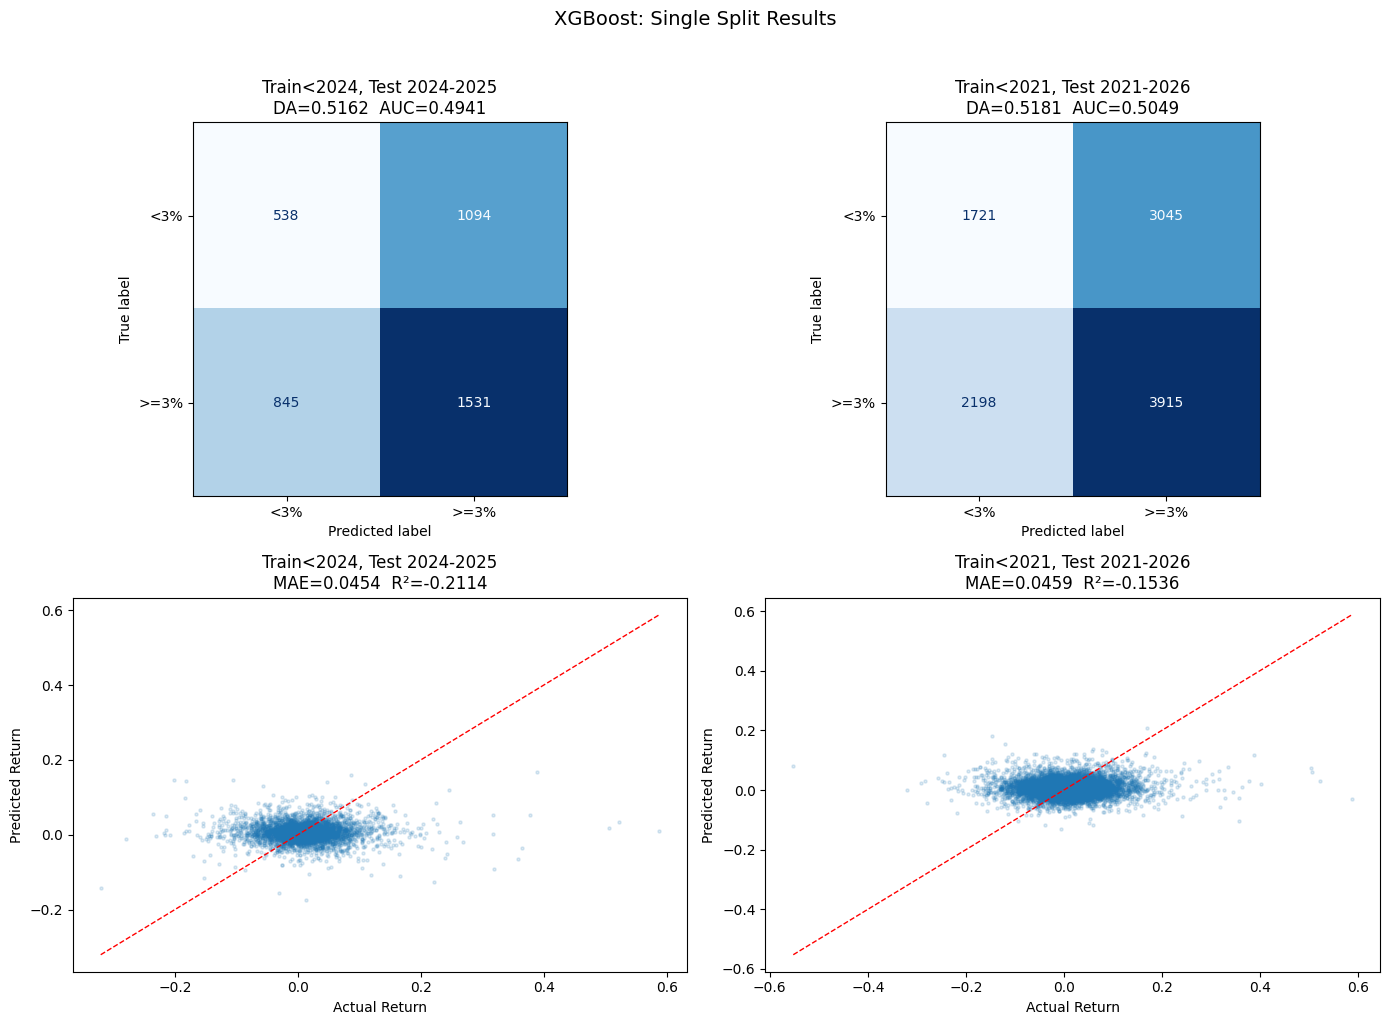

In [28]:
# ── Visualizations ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, r in enumerate(results):
    s = r['split']
    true_c = s['y_test_cls']
    true_r = s['y_test_ret']
    preds_c = r['clf']['preds']
    preds_r = r['reg']['preds']
    probs_c = r['clf']['probs']

    # Confusion Matrix
    ax = axes[0, idx]
    cm = confusion_matrix(true_c, preds_c)
    disp = ConfusionMatrixDisplay(cm, display_labels=["<3%", ">=3%"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{r['name']}\nDA={r['metrics']['DA']:.4f}  AUC={r['metrics']['AUC']:.4f}")

    # Predicted vs Actual return
    ax = axes[1, idx]
    ax.scatter(true_r, preds_r, alpha=0.15, s=5)
    lims = [min(true_r.min(), preds_r.min()), max(true_r.max(), preds_r.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel("Actual Return")
    ax.set_ylabel("Predicted Return")
    ax.set_title(f"{r['name']}\nMAE={r['metrics']['MAE']:.4f}  R²={r['metrics']['R²']:.4f}")

plt.suptitle("XGBoost: Single Split Results", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

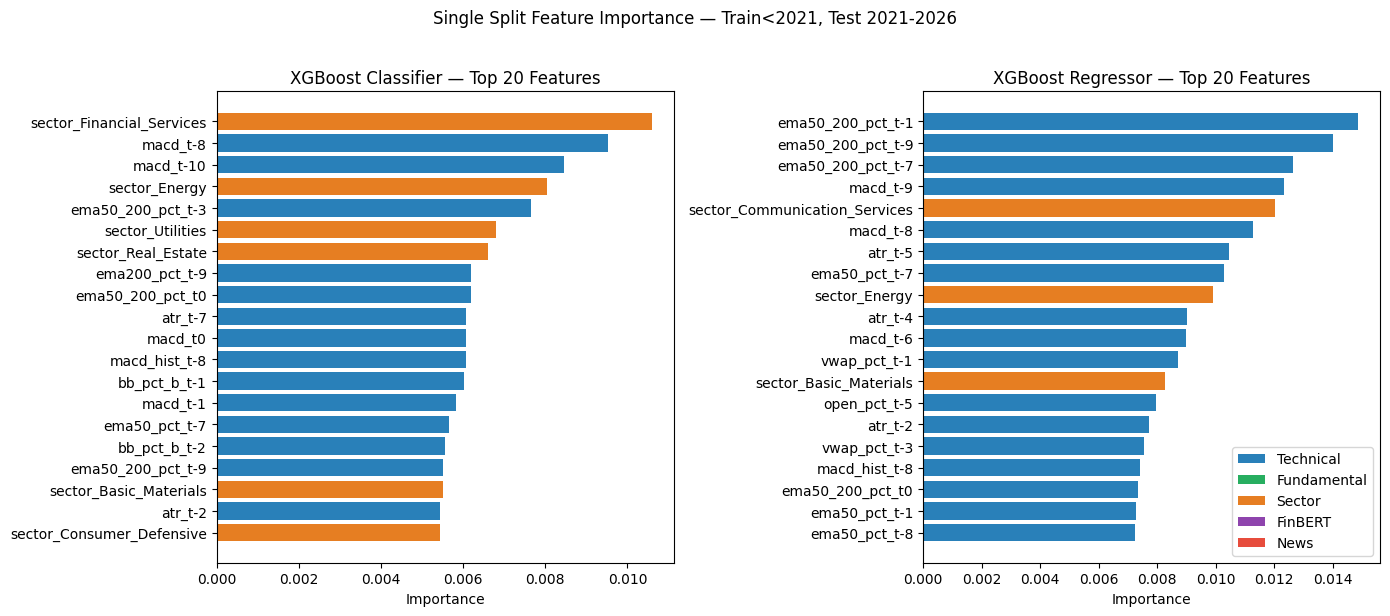

In [29]:
# ── Feature Importance (for the second / larger split) ──
r = results[1]  # Train<2021, Test 2021-2026

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

FUND_COLS = {
    "eps_growth_qoq", "revenue_growth_qoq", "gross_margin",
    "gross_margin_qoq", "debt_to_equity", "debt_to_equity_qoq",
    "fcf_margin", "fcf_margin_qoq", "roe", "roe_qoq",
}
TRANSCRIPT_COLS = {"pos_prob", "neg_prob"}
NEWS_COLS = {
    "overall_sentiment_score_pre",  "ticker_sentiment_score_pre",
    "overall_sentiment_score_post", "ticker_sentiment_score_post",
}

def feature_color(name):
    if name.startswith("sector_"):  return "#e67e22"
    if name in FUND_COLS:           return "#27ae60"
    if name in TRANSCRIPT_COLS:     return "#8e44ad"
    if name in NEWS_COLS:           return "#e74c3c"
    return "#2980b9"

for ax, (label, imp) in zip(axes, [
    ("XGBoost Classifier", r['clf']['model'].feature_importances_),
    ("XGBoost Regressor",  r['reg']['model'].feature_importances_),
]):
    top_idx   = np.argsort(imp)[-20:]
    top_names = np.array(feature_cols)[top_idx]
    top_imp   = imp[top_idx]
    colors    = [feature_color(n) for n in top_names]
    ax.barh(top_names, top_imp, color=colors)
    ax.set_title(f"{label} \u2014 Top 20 Features")
    ax.set_xlabel("Importance")

legend_elements = [
    Patch(facecolor="#2980b9", label="Technical"),
    Patch(facecolor="#27ae60", label="Fundamental"),
    Patch(facecolor="#e67e22", label="Sector"),
    Patch(facecolor="#8e44ad", label="FinBERT"),
    Patch(facecolor="#e74c3c", label="News"),
]
axes[1].legend(handles=legend_elements, loc="lower right")

plt.suptitle(f"Single Split Feature Importance — {r['name']}", y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Target Variable Deep Dive — by Sector & Distribution

In [32]:
# Reload sector name mapping (sector name was dropped after creating dummies)
df_sector_names = (
    pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
    .select(["symbol", "sector"])
    .unique()
    .with_columns(pl.col("sector").fill_null("Unknown"))
)
df_viz = df_model.join(df_sector_names, on="symbol", how="left").with_columns(
    pl.col("earnings_date").dt.year().alias("year")
)

sectors_sorted = sorted(df_viz["sector"].unique().to_list())
print(f"Sectors: {sectors_sorted}")
print(f"Rows: {len(df_viz):,}")

Sectors: ['Basic Materials', 'Communication Services', 'Consumer Cyclical', 'Consumer Defensive', 'Energy', 'Financial Services', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Unknown', 'Utilities']
Rows: 24,048


=== Target Return Descriptive Statistics ===
 statistic        value
     count 24048.000000
null_count     0.000000
      mean     0.007508
       std     0.056229
       min    -0.670921
       25%    -0.021669
       50%     0.006822
       75%     0.035613
       max     0.750633

Key Percentiles:
   1th: -0.1390 (-13.90%)
   5th: -0.0761 (-7.61%)
  25th: -0.0217 (-2.17%)
  50th: 0.0068 (0.68%)
  75th: 0.0356 (3.56%)
  90th: 0.0674 (6.74%)
  95th: 0.0920 (9.20%)
  99th: 0.1629 (16.29%)


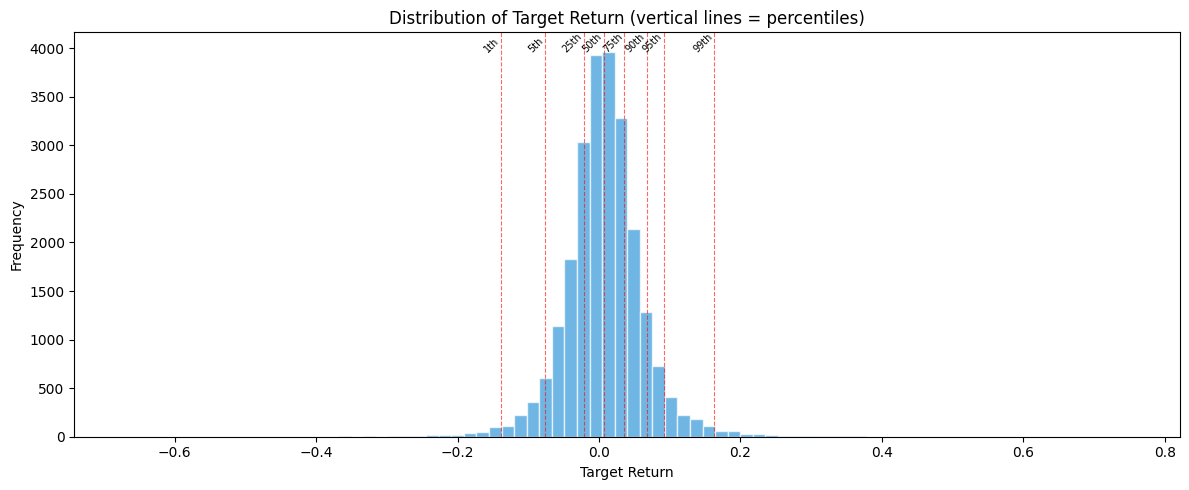

In [33]:
print("=== Target Return Descriptive Statistics ===")
stats = df_viz["target_return"].describe()
print(stats.to_pandas().to_string(index=False))
print()

percentiles = [1, 5, 25, 50, 75, 90, 95, 99]
p_vals = df_viz["target_return"].quantile([p/100 for p in percentiles])
print("Key Percentiles:")
for p, v in zip(percentiles, p_vals):
    print(f"  {p:>2}th: {v:.4f} ({v*100:.2f}%)")

fig, ax = plt.subplots(figsize=(12, 5))
returns = df_viz["target_return"].to_numpy()
ax.hist(returns, bins=80, color="#3498db", edgecolor="white", alpha=0.7)
for p, v in zip(percentiles, p_vals):
    ax.axvline(v, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(v, ax.get_ylim()[1]*0.95, f"{p}th", rotation=45, fontsize=7, ha="right")
ax.set_xlabel("Target Return")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Target Return (vertical lines = percentiles)")
plt.tight_layout()
plt.show()

In [34]:
sector_stats = df_viz.group_by("sector").agg(
    pl.len().alias("count"),
    pl.mean("target_return").alias("mean_return"),
    pl.median("target_return").alias("median_return"),
    pl.std("target_return").alias("std_return"),
    pl.mean("target_direction").alias("pct_positive"),
    pl.mean("pos_prob").alias("mean_pos_prob"),
).sort("mean_return", descending=True)

print("=== Target Return by Sector (sorted by mean return) ===\n")
print(sector_stats.to_pandas().to_string(index=False))

=== Target Return by Sector (sorted by mean return) ===

                sector  count  mean_return  median_return  std_return  pct_positive  mean_pos_prob
    Financial Services   3372     0.010837       0.010018    0.050591      0.600534       0.447324
           Industrials   3515     0.009666       0.008603    0.051054      0.579516       0.453818
                Energy   1017     0.009538       0.007228    0.077695      0.569322       0.420431
            Technology   3863     0.009515       0.009233    0.066099      0.565881       0.461821
       Basic Materials    952     0.009396       0.006562    0.060250      0.566176       0.462417
     Consumer Cyclical   2583     0.006490       0.005915    0.061283      0.548587       0.482189
            Healthcare   2845     0.005432       0.004813    0.051018      0.545870       0.471301
Communication Services   1114     0.004715       0.004204    0.066308      0.533214       0.454782
           Real Estate   1521     0.004606       0.0

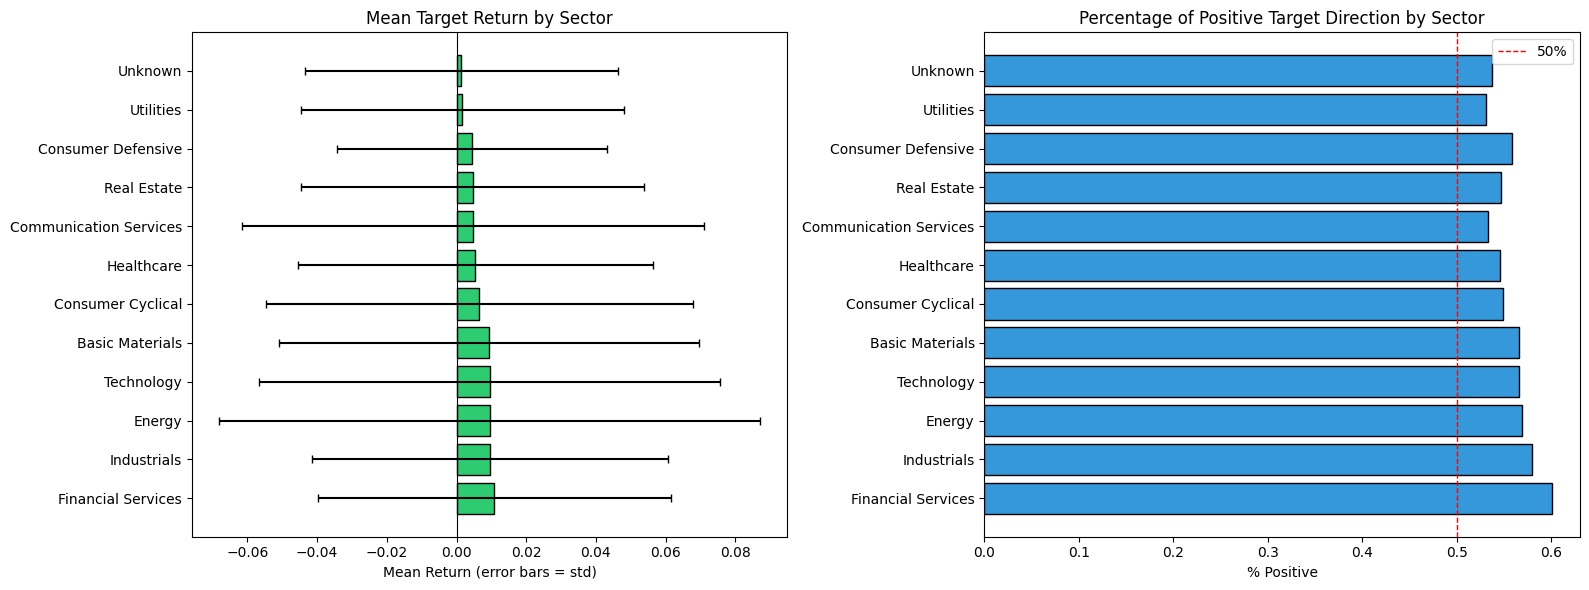

In [35]:
sector_plot = sector_stats.to_pandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: mean return by sector with std error bars
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in sector_plot["mean_return"]]
ax1.barh(sector_plot["sector"], sector_plot["mean_return"],
         xerr=sector_plot["std_return"], color=colors, edgecolor="black", capsize=3)
ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_xlabel("Mean Return (error bars = std)")
ax1.set_title("Mean Target Return by Sector")

# Right: percentage positive by sector
ax2.barh(sector_plot["sector"], sector_plot["pct_positive"],
         color="#3498db", edgecolor="black")
ax2.axvline(0.5, color="red", linestyle="--", linewidth=1, label="50%")
ax2.set_xlabel("% Positive")
ax2.set_title("Percentage of Positive Target Direction by Sector")
ax2.legend()

plt.tight_layout()
plt.show()

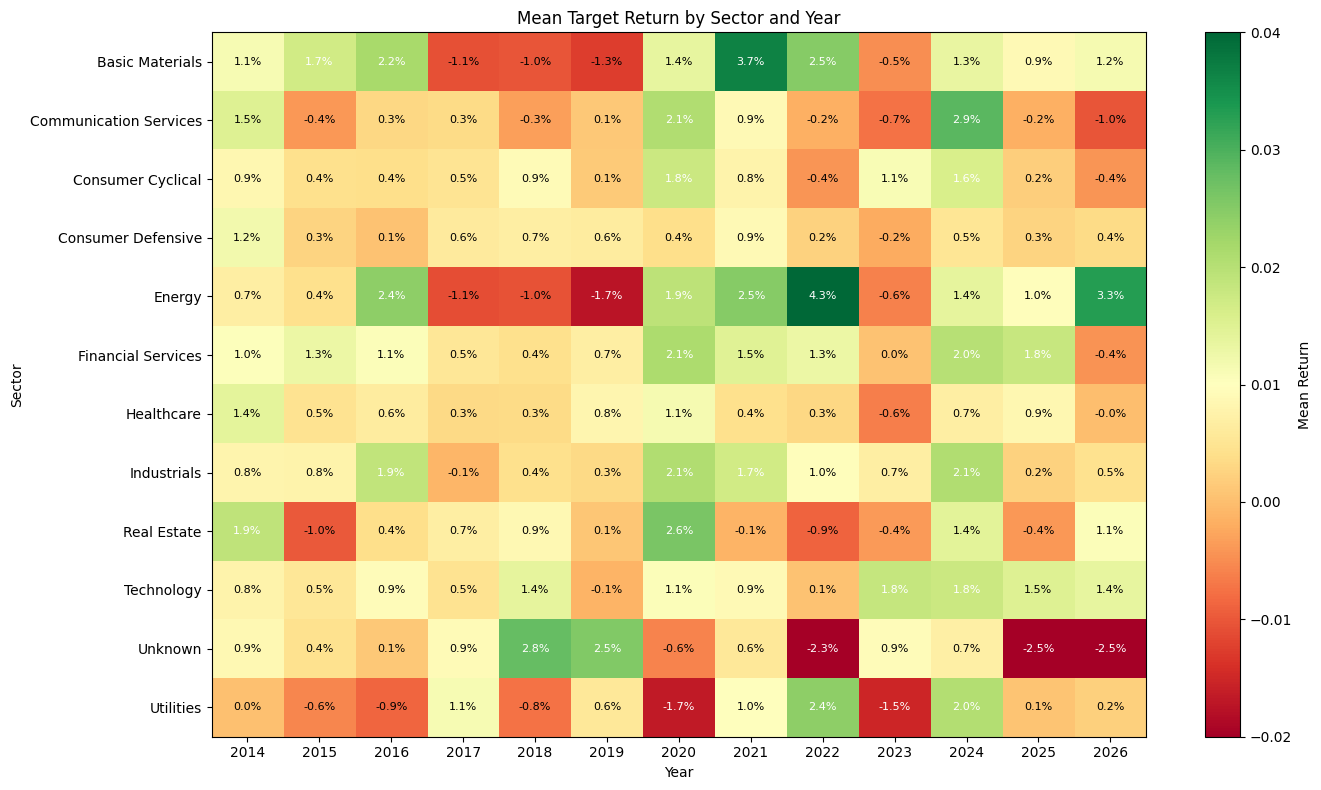

In [36]:
sector_year = df_viz.group_by(["sector", "year"]).agg(
    pl.mean("target_return").alias("mean_return")
).sort("year").to_pandas()

pivot = sector_year.pivot_table(
    index="sector", columns="year", values="mean_return", aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=-0.02, vmax=0.04)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Year")
ax.set_ylabel("Sector")
ax.set_title("Mean Target Return by Sector and Year")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        ax.text(j, i, f"{v:.1%}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 0.015 else "black")

plt.colorbar(im, ax=ax, label="Mean Return")
plt.tight_layout()
plt.show()